<a href="https://colab.research.google.com/github/LarrySnyder/ASJ/blob/main/compas/COMPAS_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMPAS Data

This notebook experiments on the ProPublica COMPAS dataset. It is based on https://afraenkel.github.io/fairness-book/content/04-compas.html.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load and Parse the Data

First, we will download the dataset and print the records for two defendants to get a sense of what the dataset contains.

The data were collected by ProPublica via the Freedom of Information Act. This dataset comes from pretrial detention hearings in Broward County, Florida, in 2013.

The variables we will use are: sex/gender, race/ethnicity, age, purpose of assessment (e.g. pretrial release), type of assessment (recidivism, violent recidivism), and the risk-score itself.

In [3]:
defendants = pd.read_csv('https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-raw.csv')

with pd.option_context('display.max_rows', 30):
    print(defendants.loc[[32647, 5032]].drop(['FirstName', 'LastName', 'MiddleName'], axis=1).T)

                                      32647               5032 
Person_ID                             60304               52305
AssessmentID                          69187               58972
Case_ID                               62725               53582
Agency_Text                        PRETRIAL           Probation
Sex_Code_Text                          Male                Male
Ethnic_Code_Text           African-American           Caucasian
DateOfBirth                        07/05/95            05/04/89
ScaleSet_ID                              22                  22
ScaleSet                 Risk and Prescreen  Risk and Prescreen
AssessmentReason                     Intake              Intake
Language                            English             English
LegalStatus                        Pretrial       Post Sentence
CustodyStatus                   Jail Inmate           Probation
MaritalStatus                        Single              Single
Screening_Date                 1/10/14 0

The COMPAS dataset contains three types of risk scores: risk of violence, risk of recidivism, and risk of failure to appear. We are only interested in risk of recidivism, so we will exclude all the other records. 

In [4]:
defendants = defendants[defendants.DisplayText == 'Risk of Recidivism']


The number of defendants screened by COMPAS for Risk of Recidivism is:

In [5]:
len(defendants)

20281

A few dozen records have COMPAS scores set to -1. Let's get rid of those records too.

In [6]:
defendants = defendants[defendants.DecileScore > 0]
len(defendants)

20245

## Basic Data Analysis

Let's do some basic data analysis. First we'll get a count of the number of defendants by "sex" and by "ethnicity" (the terms used in the dataset).

The plots show that almost 80% of defendants are male. Roughly 45% are African-American and 35% are Caucasian.

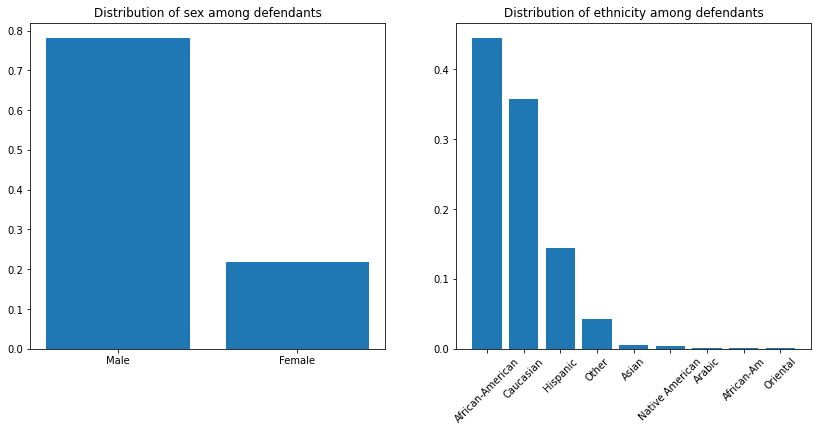

In [7]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

# Sex_Code_Text histogram.
sex_code_text_counts = defendants.Sex_Code_Text.value_counts(normalize=True)
axes[0].bar(sex_code_text_counts.index, sex_code_text_counts)
axes[0].set_title('Distribution of sex among defendants')

# Ethnic_Code_Text histogram.
ethnic_code_text_counts = defendants.Ethnic_Code_Text.value_counts(normalize=True)
axes[1].bar(ethnic_code_text_counts.index, ethnic_code_text_counts)
plt.xticks(rotation=45)
axes[1].set_title('Distribution of ethnicity among defendants');

Next, let's plot the COMPAS scores, i.e., the recidivism-risk "deciles" (scores on a 10-point scale).

The most frequent score is 1 (lowest risk), and the frequencies taper off from there.

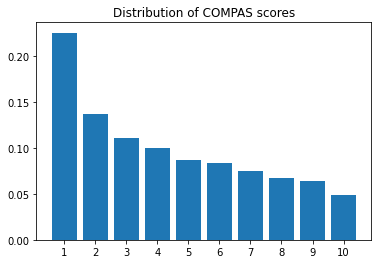

In [8]:
decilescore_counts = defendants.DecileScore.value_counts(normalize=True)
plt.bar(decilescore_counts.index, decilescore_counts)
plt.title('Distribution of COMPAS scores')
plt.xticks(range(1, 11));

There's a big difference between the distribution of scores for African-American defendants vs. Caucasian ones:

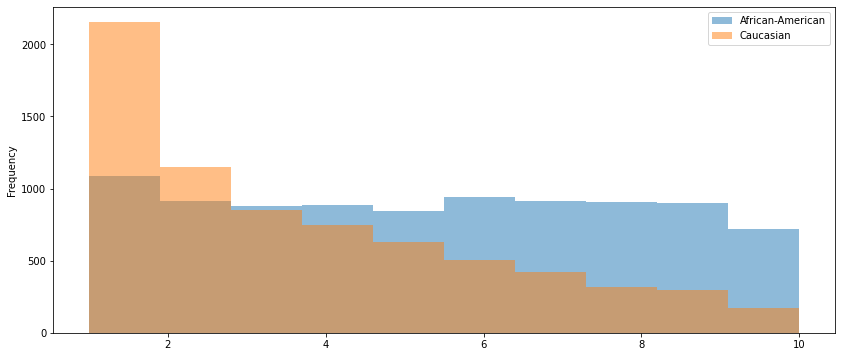

In [9]:
(
  defendants
  .loc[defendants.Ethnic_Code_Text.isin(['African-American', 'Caucasian'])]
  .groupby('Ethnic_Code_Text')
  .DecileScore
  .plot(kind='hist', alpha=0.5, legend=True, figsize=(14,6))
);

## COMPAS Model Accuracy

Next, we want to explore the accuracy of the COMPAS model. ProPublica also conducted public records research to determine which defendants re-offended in the two years following their COMPAS screening. They were able to follow up on approximately half the defendants. See ProPublica’s methodology for how this dataset was collected and joined to the one above.

We'll download this dataset. The dataset contains a field called `two_year_recid` that equals 1 if the defendant re-offended within two years of screening and equals 0 otherwise. It also lists the defendant's COMPAS score (from the first dataset). We'll add a column for the COMPAS decision: either 0 if the COMPAS model assigned the defendant a score of "Low" (decile score ≤ 4) or 1 if the model assigned a score of "Medium" (decile score between 5 and 7) or "High" (decile score ≥ 8).

(Note: "Re-offended" really means "was convicted of another crime." Obviously, not all crimes results in a report, arrest, and conviction; and conversely, just because the defendant was convicted of the crime does not mean with certainty that the committed the crime. However, we will treat the `two_year_recid` field as though it accurately indicates whether the defendant did commit a crime within two years.)

Since we're interested in comparing COMPAS scores and accuracy for African-American and Caucasian defendants, we'll only include those ethnicities. The dataset contains lots of fields that we'll omit. 


# (THE NOTEBOOK SHOULD START HERE INSTEAD)

In [10]:
url = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv'
recidivism = (
    pd.read_csv(url)
    [['age_cat', 'sex', 'race', 'decile_score', 'score_text', 'two_year_recid']]
    .loc[lambda x:x.race.isin(['African-American', 'Caucasian'])]
    .assign(COMPAS_Decision=lambda x:x['score_text'].replace({'Low': 0, 'Medium':1, 'High': 1}))
)

In [11]:
recidivism.head(n=10)

,age_cat,sex,race,decile_score,score_text,two_year_recid,COMPAS_Decision
1,25 - 45,Male,African-American,3,Low,1,0
2,Less than 25,Male,African-American,4,Low,1,0
3,Less than 25,Male,African-American,8,High,0,1
6,25 - 45,Male,Caucasian,6,Medium,1,1
8,25 - 45,Female,Caucasian,1,Low,0,0
9,Less than 25,Male,Caucasian,3,Low,1,0
10,25 - 45,Male,Caucasian,4,Low,0,0
11,Less than 25,Male,African-American,6,Medium,1,1
12,25 - 45,Female,Caucasian,1,Low,0,0
13,25 - 45,Male,African-American,4,Low,0,0


Let's examine the accuracy of `COMPAS Decision` as a predictor for `two_year_recid`.

Each defendant has a value for `COMPAS Decision` (either 0 or 1) and a value for `two_year_recid` (either 0 or 1). The table below shows how these values line up with each other.

First, 50.8% of defendants were predicted not to recidivate (`COMPAS_Decision` = 0) and 49.2% were predicted to recidivate. This is pretty close to the actual percentage who did not recidivate (53.4%) and who did (46.6%).

On the other hand, the overall accuracy is relatively low: 34.6% were predicted not to recidivate and didn't (`COMPAS_Decision` = `two_year_recid` = 0) and 30.5% were predicted to recidivate and did (`COMPAS_Decision` = `two_year_recid` = 1), for a total accuracy of 65.1%. 

On the third hand, the percentage of defendants who were predicted *not to* recidivate but who *did* recidivate (the **false negative rate (FNR)**) and the percentage who were predicted *to* recidivate but who *did not* recidivate (the **false positive rate (FPR)**) are roughly equal: 16.2% vs. 18.8%. 

(This kind of table—which shows true and false positives and negatives—is sometimes called a **confusion matrix.**)

In [30]:
pd.crosstab(recidivism['COMPAS_Decision'], recidivism['two_year_recid'], normalize=True, margins=True)

two_year_recid,0,1,All
COMPAS_Decision,,,
0,0.346179,0.161463,0.507642
1,0.187642,0.304715,0.492358
All,0.533821,0.466179,1.000000


The plot below shows the frequency of decile scores defendants who did not recidivate (blue bars) and for those who did (orange bars). 

In the aggregate, the model assigned lower decile scores to defendants who wound up not recidivating and higher decile scores who defendents who did. That's good. But there is a lot of overlap between the two groups of bars, suggesting that the model is not a particularly accurate predictor.

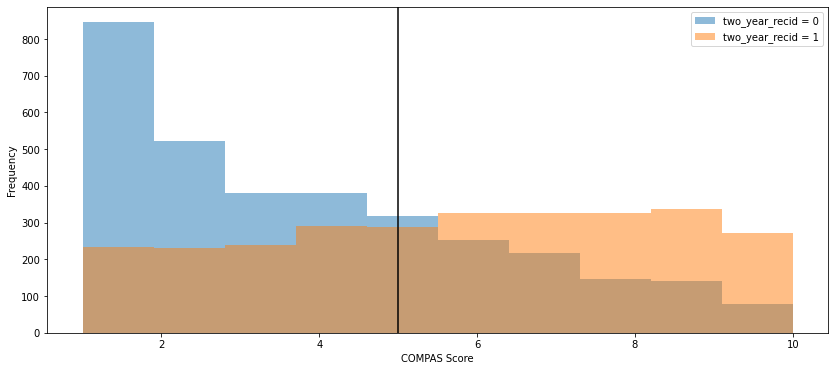

In [57]:
ax = recidivism.groupby('two_year_recid').decile_score.plot(kind='hist', alpha=0.5, figsize=(14,6))
plt.xlabel('COMPAS Score')
plt.legend(['two_year_recid = 0', 'two_year_recid = 1'])
plt.axvline(5, color='k');

COMPAS basically draws a line at a specific decile score and says "anybody at or above this line is predicted to recidivate; anybody below it is predicted not to." Northpointe set that line at 5. This is called a **threshold model.**

Let's calculate our own threshold model. First we'll set the threshold at 5 to confirm that we get the same results as COMPAS.

In [41]:
threshold = 5

recidivism = recidivism.assign(My_Decision = 1 * (recidivism['decile_score'] >= threshold)) # 1 * converts Booleans to integers
recidivism.head()

,age_cat,sex,race,decile_score,score_text,two_year_recid,COMPAS_Decision,My_Decision
1,25 - 45,Male,African-American,3,Low,1,0,0
2,Less than 25,Male,African-American,4,Low,1,0,0
3,Less than 25,Male,African-American,8,High,0,1,1
6,25 - 45,Male,Caucasian,6,Medium,1,1,1
8,25 - 45,Female,Caucasian,1,Low,0,0,0


Check that `My_Decision` agrees with `COMPAS_Decision`.


In [44]:
# Does `COMPAS_Decision` column equal `My_Decision` column?
recidivism['COMPAS_Decision'].equals(recidivism['My_Decision'])

True

Now let's try other thresholds. Experiment with the `threshold` value in the code below. For each value you try, note the FPR and FNR.

**What value of `threshold` would you recommend, if you were designing the COMPAS system?**

In [54]:
threshold = 7

recidivism = recidivism.assign(My_Decision = 1 * (recidivism['decile_score'] >= threshold)) # 1 * converts Booleans to integers

pd.crosstab(recidivism['My_Decision'], recidivism['two_year_recid'], normalize=True, margins=True)

two_year_recid,0,1,All
My_Decision,,,
0,0.439024,0.261138,0.700163
1,0.094797,0.205041,0.299837
All,0.533821,0.466179,1.000000


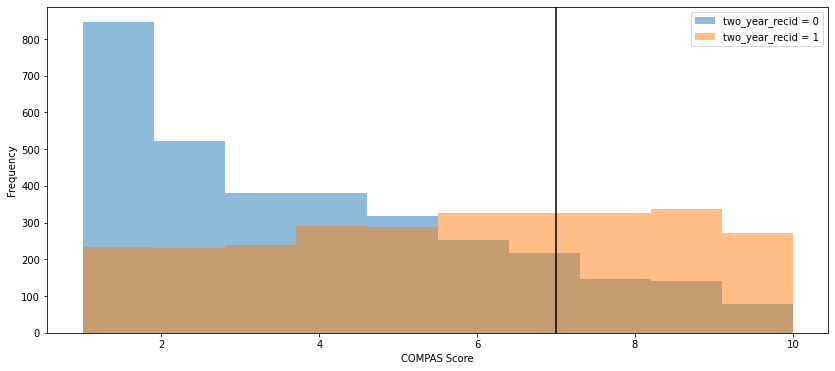

In [55]:
ax = recidivism.groupby('two_year_recid').decile_score.plot(kind='hist', alpha=0.5, figsize=(14,6))
plt.xlabel('COMPAS Score')
plt.legend(['two_year_recid = 0', 'two_year_recid = 1'])
plt.axvline(threshold, color='k');